In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Operator
from tqdm.notebook import tqdm
from weylchamber import WeylChamber, c1c2c3
from hetero_isas.zz_parallel_drive.bgate import BGate
from hetero_isas.zz_parallel_drive.hamiltonian import ZZ_ParallelDrive
from qiskit.circuit.library import iSwapGate, CXGate, CZGate
import matplotlib.pyplot as plt
from itertools import product, permutations
from matplotlib import cm

N = 1_000
REDUCE_COORD = False

In [12]:
### NOTE deprecated
# the methods from this notebook were refasctored into python modules
# see 08_point_clouds.ipynb

In [ ]:
GATE_LABELS = {0: "I", 1: "U1", 2: "U2", 3: "U3"}


def _generate_label(sequence_set, basis_gate_str):
    labels = []
    for seq in sequence_set:
        label_parts = []
        for i in range(len(seq)):
            label_parts.append(f"({GATE_LABELS[seq[i][0]]}⊗{GATE_LABELS[seq[i][1]]})")
        label = f"{basis_gate_str}-"
        label += f"-{basis_gate_str}-".join(label_parts)
        label += f"-{basis_gate_str}"
        labels.append(label)
    return labels

In [3]:
def _add_u_gate(qc, gate_type, qubit, param_idx):
    if gate_type == 3:
        qc.u(
            Parameter(f"x{param_idx}"),
            Parameter(f"x{param_idx+1}"),
            Parameter(f"x{param_idx+2}"),
            qubit,
        )
    elif gate_type == 2:
        qc.u(np.pi / 2, Parameter(f"x{param_idx}"), Parameter(f"x{param_idx+1}"), qubit)
    elif gate_type == 1:
        qc.u(0, 0, Parameter(f"x{param_idx}"), qubit)
    else:
        pass  # identity
    return qc


def generate_circuit(sequence, basis_gate=BGate(), num_samples=N):
    qc = QuantumCircuit(2)
    param_idx = 0
    num_layers = len(sequence)
    for i in range(num_layers):
        qc.append(basis_gate, [0, 1])
        qc = _add_u_gate(qc, sequence[i][0], 0, param_idx=param_idx)
        qc = _add_u_gate(qc, sequence[i][1], 1, param_idx=param_idx + 3)
        param_idx += 6
    qc.append(basis_gate, [0, 1])

    temp_coord_list = []
    # for _ in tqdm(range(num_samples)):
    for _ in range(num_samples):
        temp_qc = qc.assign_parameters(
            {param: np.random.uniform(0, 2 * np.pi) for param in qc.parameters}
        )
        temp_coord_list.append(list(c1c2c3(Operator(temp_qc).data)))
    return temp_coord_list

In [4]:
def _generate_1q_sequences(interior_layers, include_identity=False):
    gate_options = [0, 1, 2, 3] if include_identity else [1, 2, 3]
    circuit_layers = list(
        product(product(gate_options, repeat=2), repeat=interior_layers)
    )
    unique_circuits = set()
    # prune for symmetries
    for seq in circuit_layers:
        rev_seq = seq[::-1]
        swapped_seq = tuple((j, i) for i, j in seq)
        rev_swapped_seq = swapped_seq[::-1]
        min_seq = min(seq, rev_seq, swapped_seq, rev_swapped_seq)
        unique_circuits.add(min_seq)
    return sorted(unique_circuits, reverse=True)


# _generate_1q_sequences(2)

In [5]:
GATE_LABELS = {0: "I", 1: "U1", 2: "U2", 3: "U3"}


def _generate_label(sequence_set, basis_gate_str):
    labels = []
    for seq in sequence_set:
        label_parts = []
        for i in range(len(seq)):
            label_parts.append(f"({GATE_LABELS[seq[i][0]]}⊗{GATE_LABELS[seq[i][1]]})")
        label = f"{basis_gate_str}-"
        label += f"-{basis_gate_str}-".join(label_parts)
        label += f"-{basis_gate_str}"
        labels.append(label)
    return labels

In [6]:
# FIXME, maybe too simple
# want to separate 2Q and 1Q fidelity from strictly duration
# could count total instead of critical path duration
# FIXME ignores costs from the before/after single-qubit gates
# we could just assume a u3 suffix always required
PULSE_COST_RATIO = 2  # 100ns (2Q) to 50ns (1Q)


def pulse_cost(sequence_set):
    """Return tuple (depth, total)."""
    c = []
    costs_1q = {3: 2, 2: 1, 1: 0, 0: 0}
    for seq in sequence_set:
        w1, w2 = 0, 0
        for layer in seq:
            w1 += costs_1q[layer[0]]
            w2 += costs_1q[layer[1]]
        depth_c = 2 * PULSE_COST_RATIO * len(seq) + max(w1, w2)
        total_c = 2 * PULSE_COST_RATIO * len(seq) + w1 + w2
        c.append((depth_c, total_c))
    return c

In [7]:
def plot_weyl_chamber(coord_lists, labels, pulse_costs):
    n = len(coord_lists)
    colors = cm.tab10(np.linspace(0, 1.0, 10))
    max_cols = 6
    num_rows = (n + max_cols - 1) // max_cols
    fig, axs = plt.subplots(
        num_rows,
        max_cols,
        subplot_kw={"projection": "3d"},
        figsize=(max_cols * 5, num_rows * 5),
    )
    axs = axs.flatten()
    for i, inner_coord_list in enumerate(coord_lists):
        ax = axs[i] if n > 1 else axs
        w = WeylChamber()
        w.labels = {}
        w.render(ax)
        w.ax.scatter3D(*zip(*inner_coord_list), color=colors[i % len(colors)])
        w.ax.set_title(f"{labels[i]}\n cost: {pulse_costs[i]}")
        # w.ax.set_suptitle(f"")
    for j in range(i + 1, num_rows * max_cols):
        fig.delaxes(axs[j])

  0%|          | 0/6 [00:00<?, ?it/s]

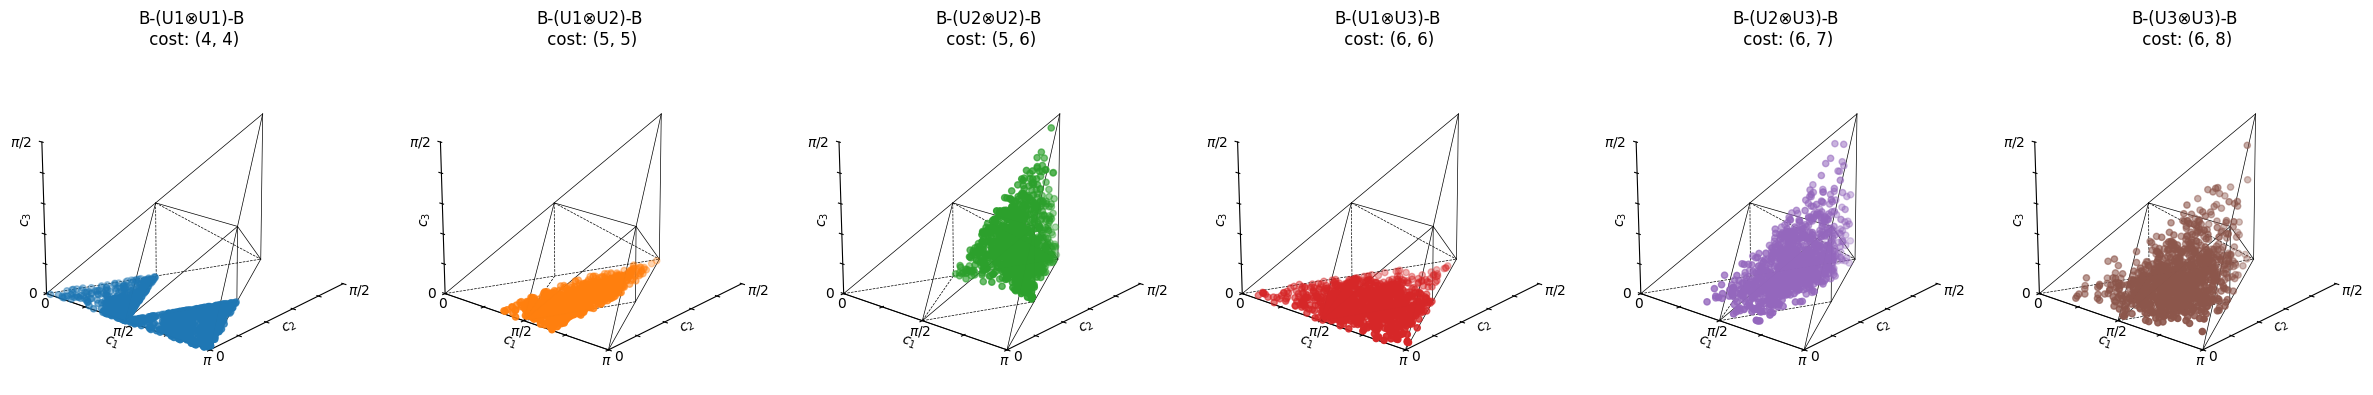

In [8]:
interior_layers = 1
basis_gate = BGate()
unique_combinations = _generate_1q_sequences(interior_layers)
labels = _generate_label(unique_combinations, "B")
pulse_costs = pulse_cost(unique_combinations)
b_coord_list = [
    generate_circuit(comb, basis_gate, N) for comb in tqdm(unique_combinations)
]
sorted_costs, sorted_coords, sorted_labels = zip(
    *sorted(zip(pulse_costs, b_coord_list, labels))
)
plot_weyl_chamber(sorted_coords, sorted_labels, sorted_costs)

  0%|          | 0/33 [00:00<?, ?it/s]

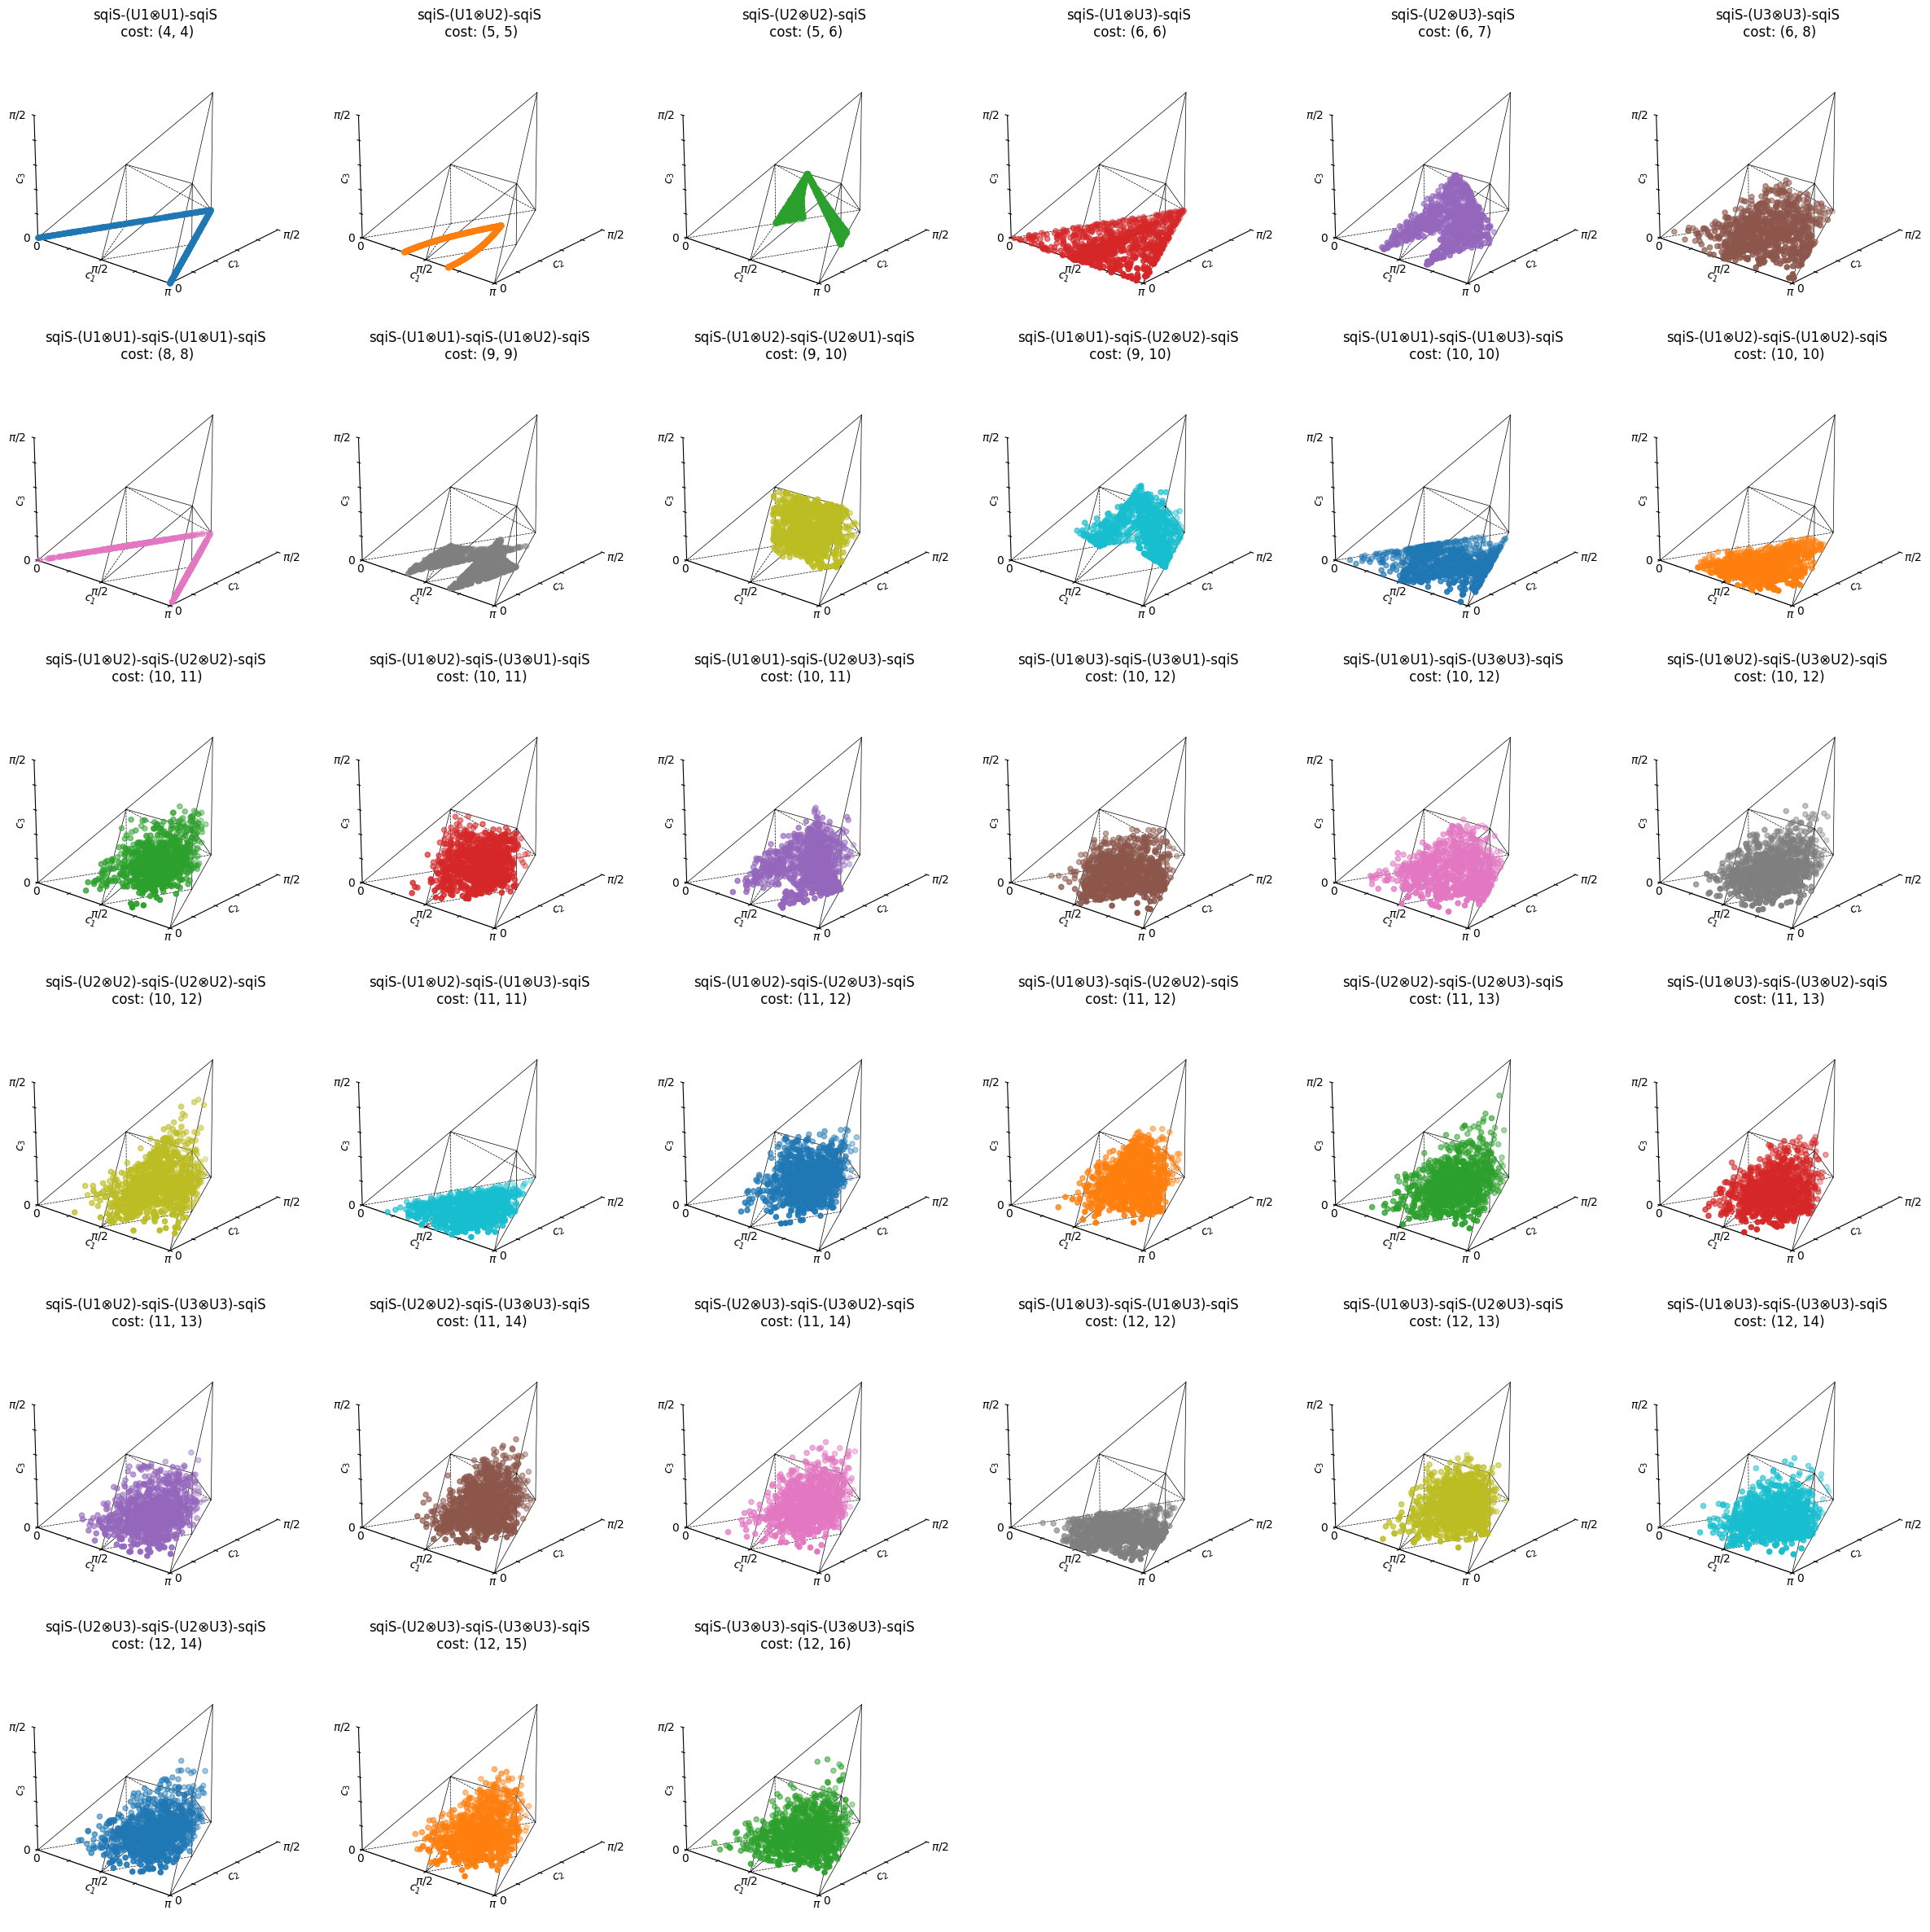

In [9]:
basis_gate = iSwapGate().power(1 / 2)
unique_combinations = _generate_1q_sequences(1) + _generate_1q_sequences(2)
labels = _generate_label(unique_combinations, "sqiS")
pulse_costs = pulse_cost(unique_combinations)
iswap_coord_list = [
    generate_circuit(comb, basis_gate, N) for comb in tqdm(unique_combinations)
]
sorted_costs, sorted_coords, sorted_labels = zip(
    *sorted(zip(pulse_costs, iswap_coord_list, labels))
)
plot_weyl_chamber(sorted_coords, sorted_labels, sorted_costs)

  0%|          | 0/27 [00:00<?, ?it/s]

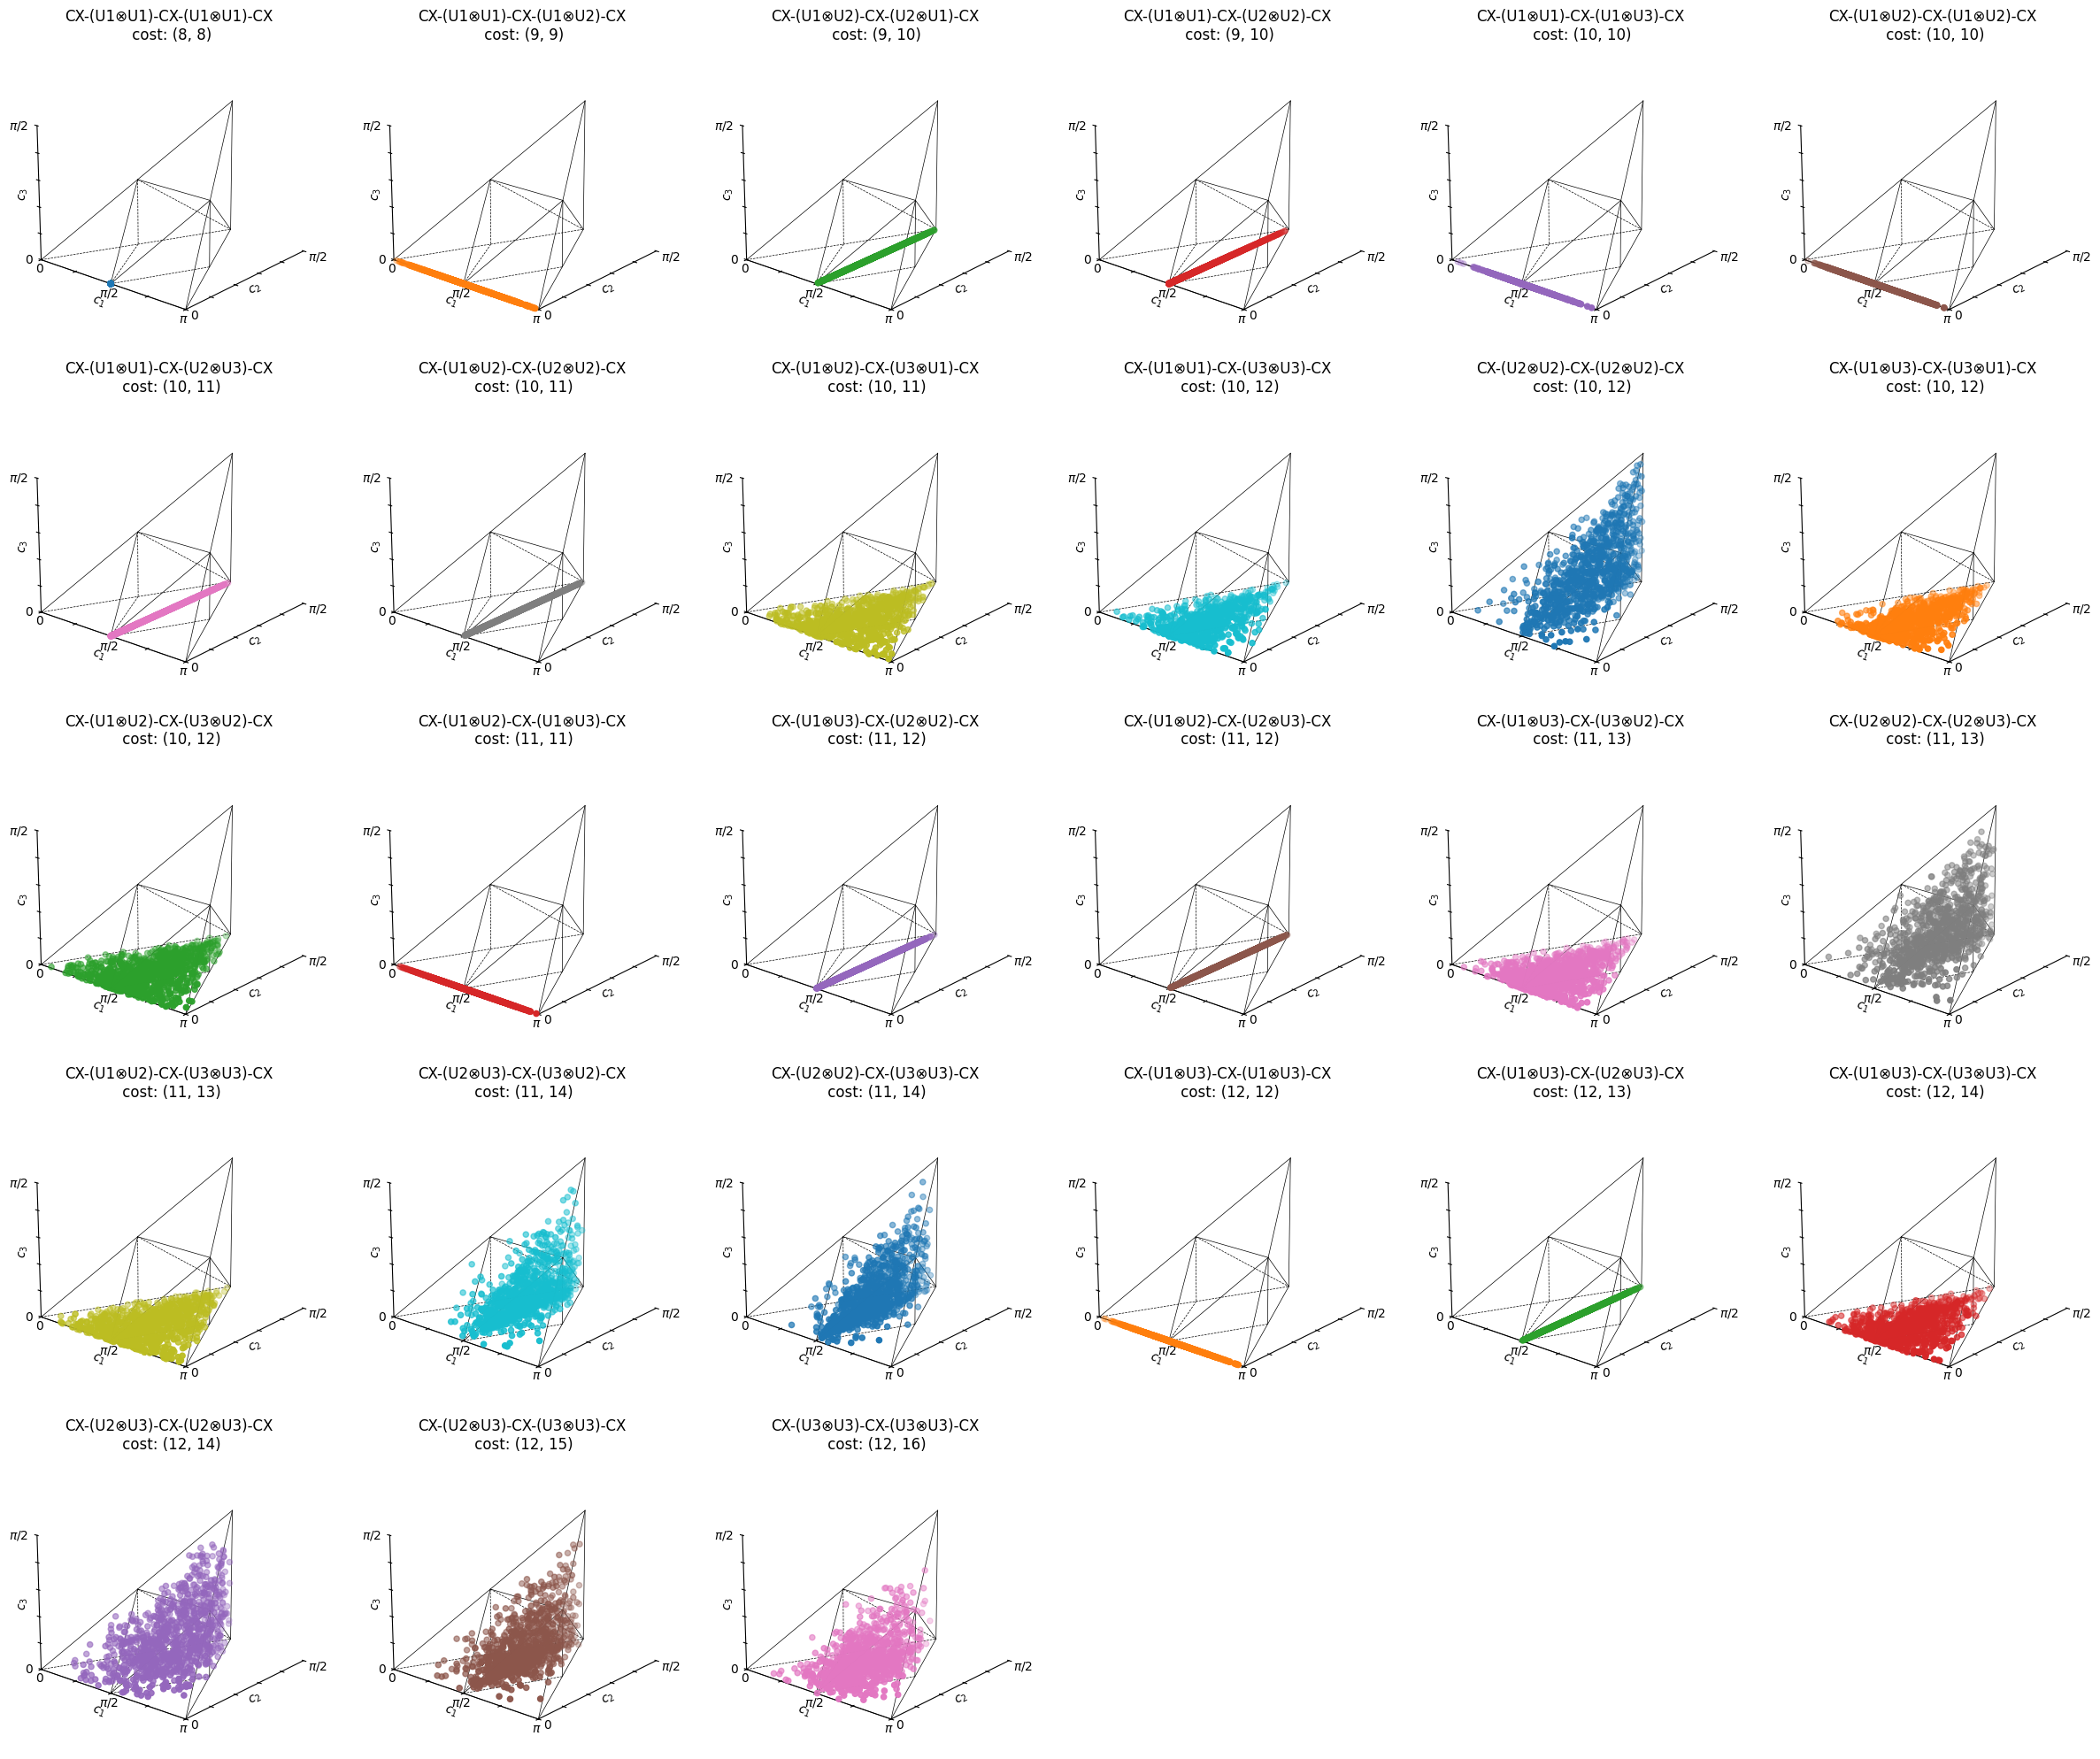

In [10]:
interior_layers = 2
basis_gate = CXGate()
unique_combinations = _generate_1q_sequences(interior_layers)
labels = _generate_label(unique_combinations, "CX")
pulse_costs = pulse_cost(unique_combinations)
cx_coord_list = [
    generate_circuit(comb, basis_gate, N) for comb in tqdm(unique_combinations)
]
sorted_costs, sorted_coords, sorted_labels = zip(
    *sorted(zip(pulse_costs, cx_coord_list, labels))
)
plot_weyl_chamber(sorted_coords, sorted_labels, sorted_costs)

  0%|          | 0/27 [00:00<?, ?it/s]

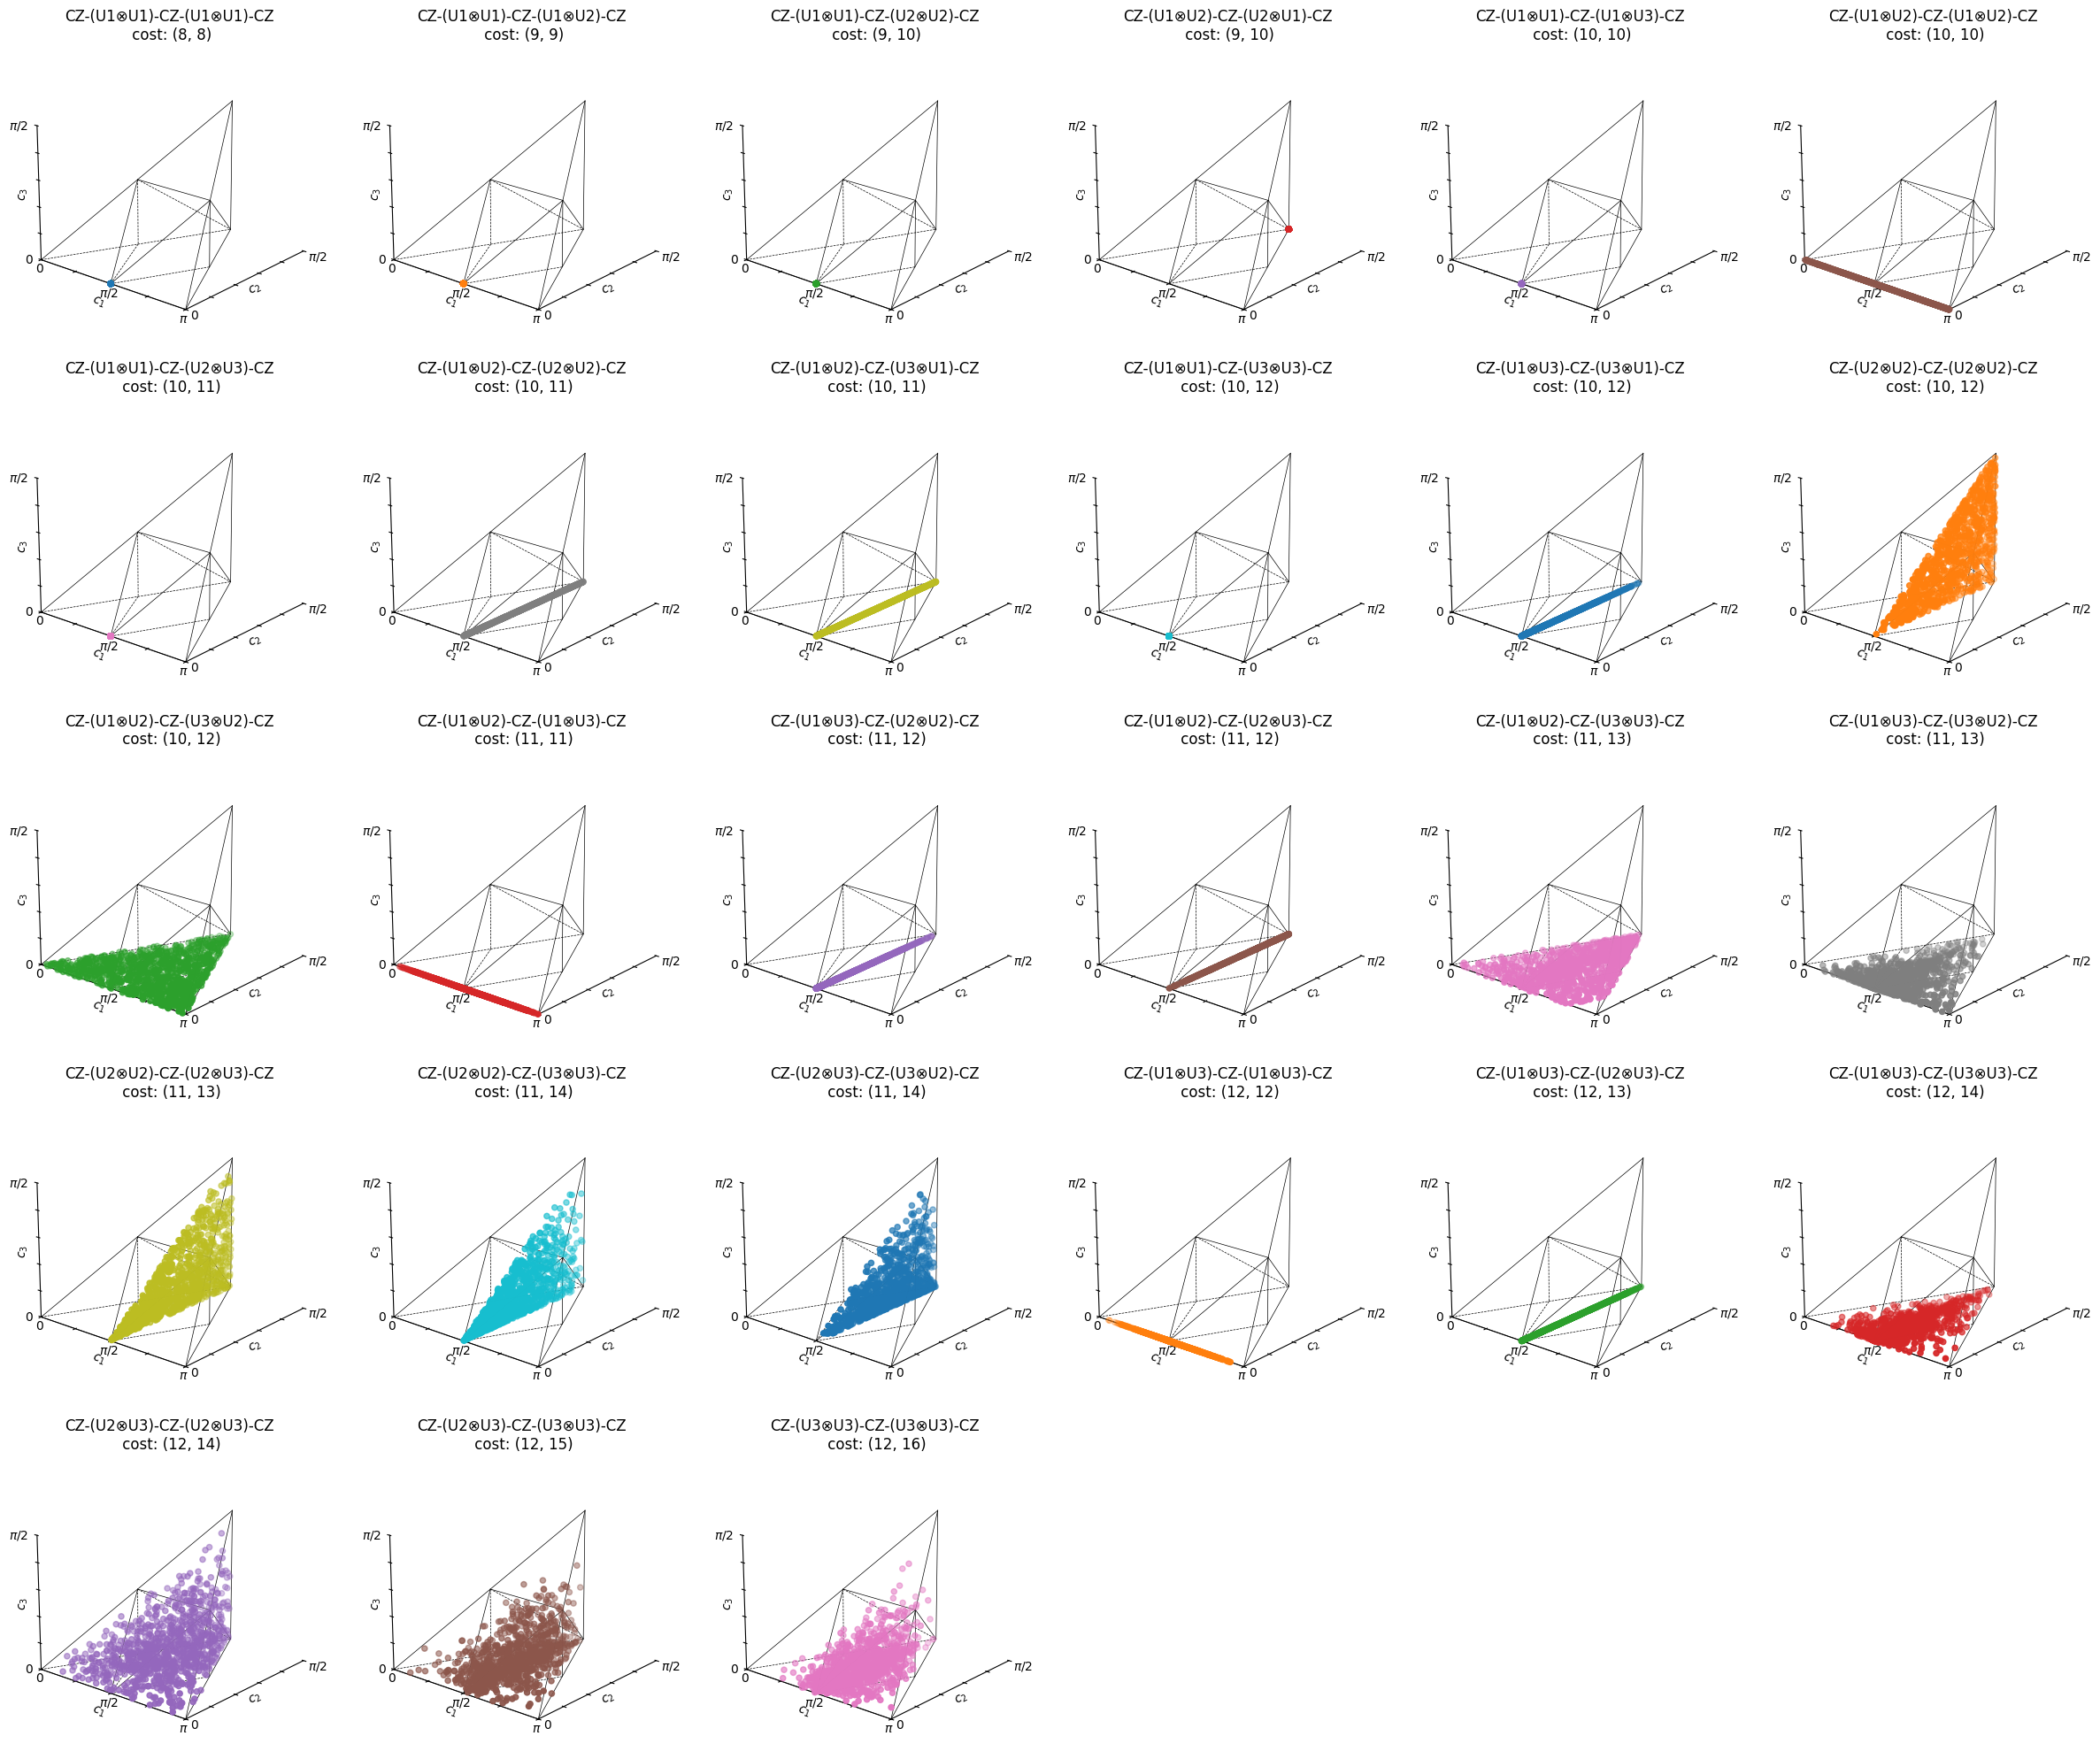

In [11]:
interior_layers = 2
basis_gate = CZGate()
unique_combinations = _generate_1q_sequences(interior_layers)
labels = _generate_label(unique_combinations, "CZ")
pulse_costs = pulse_cost(unique_combinations)
cz_coord_list = [
    generate_circuit(comb, basis_gate, N) for comb in tqdm(unique_combinations)
]
sorted_costs, sorted_coords, sorted_labels = zip(
    *sorted(zip(pulse_costs, cz_coord_list, labels))
)
plot_weyl_chamber(sorted_coords, sorted_labels, sorted_costs)